In [ ]:
# ==========================================================
# PASO 1: INSTALAR LIBRERÍAS NECESARIAS
# ==========================================================
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [ ]:
# ==========================================================
# PASO 2: IMPORTAR LIBRERÍAS
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# ==========================================================
# PASO 3: SUBIR EL ARCHIVO sample_sales_data.csv
# ==========================================================
from google.colab import files
uploaded = files.upload()

Saving sales_data_sample.csv to sales_data_sample (1).csv


In [ ]:
# ==========================================================
# PASO 4: CARGAR EL DATASET
# ==========================================================
df = pd.read_csv("sales_data_sample.csv", encoding="latin1")
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [ ]:
# ==========================================================
# PASO 5: INFORMACIÓN GENERAL DEL DATASET
# ==========================================================
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nPrimeras filas:")
df.head()

Dimensiones: (2823, 25)

Columnas:
['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

Tipos de datos:
ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY            object

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [ ]:
# ==========================================================
# PASO 6: ESTADÍSTICAS DESCRIPTIVAS
# ==========================================================
df.describe(include='all')

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823,2823,2823.000000,2823.000000,2823.00000,...,2823,302,2823,1337,2747,2823,1749,2823,2823,2823
unique,NaN,NaN,NaN,NaN,NaN,252,6,NaN,NaN,NaN,...,92,9,73,16,73,19,3,77,72,3
top,NaN,NaN,NaN,NaN,NaN,11/14/2003 0:00,Shipped,NaN,NaN,NaN,...,"C/ Moralzarzal, 86",Level 3,Madrid,CA,28034,USA,EMEA,Freyre,Diego,Medium
freq,NaN,NaN,NaN,NaN,NaN,38,2617,NaN,NaN,NaN,...,259,55,304,416,259,1004,1407,259,259,1384
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,NaN,NaN,2.717676,7.092455,2003.81509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,92.085478,9.741443,20.174277,4.225841,1841.865106,NaN,NaN,1.203878,3.656633,0.69967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,10100.000000,6.000000,26.880000,1.000000,482.130000,NaN,NaN,1.000000,1.000000,2003.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,NaN,NaN,2.000000,4.000000,2003.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,NaN,NaN,3.000000,8.000000,2004.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,NaN,NaN,4.000000,11.000000,2004.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ==========================================================
# PASO 7: VERIFICAR VALORES NULOS
# ==========================================================
print(df.isnull().sum())

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64


In [ ]:
# ==========================================================
# PASO 8: ELIMINAR FILAS CON VALORES NULOS
# ==========================================================
df = df.dropna()
print("Nuevo tamaño del dataset:", df.shape)

Nuevo tamaño del dataset: (147, 25)


In [ ]:
# ==========================================================
# PASO 9: CONVERTIR FECHAS
# ==========================================================
if 'ORDERDATE' in df.columns:
    df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
10,10223,37,100.00,1,3965.66,2004-02-20,Shipped,1,2,2004,...,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium
21,10361,20,72.55,13,1451.00,2004-12-17,Shipped,4,12,2004,...,"Monitor Money Building, 815 Pacific Hwy",Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Small
40,10270,21,100.00,9,4905.39,2004-07-19,Shipped,3,7,2004,...,"Monitor Money Building, 815 Pacific Hwy",Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Medium
47,10347,30,100.00,1,3944.70,2004-11-29,Shipped,4,11,2004,...,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium
51,10391,24,100.00,4,2416.56,2005-03-09,Shipped,1,3,2005,...,201 Miller Street,Level 15,North Sydney,NSW,2060,Australia,APAC,O'Hara,Anna,Small


In [ ]:
# ==========================================================
# PASO 10: IDENTIFICAR COLUMNAS NUMÉRICAS
# ==========================================================
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columnas numéricas:")
print(columnas_numericas)

Columnas numéricas:
['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'MSRP']


In [ ]:
# ==========================================================
# PASO 11: NORMALIZACIÓN MIN-MAX
# ==========================================================
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()

df_minmax[columnas_numericas] = scaler_minmax.fit_transform(df[columnas_numericas])

df_minmax[columnas_numericas].head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
10,0.343333,0.431373,1.00000,0.000000,0.363235,0.000000,0.090909,0.5,0.342541
21,0.803333,0.098039,0.62459,0.857143,0.087555,1.000000,1.000000,0.5,0.342541
40,0.500000,0.117647,1.00000,0.571429,0.466256,0.666667,0.545455,0.5,1.000000
47,0.756667,0.294118,1.00000,0.000000,0.360937,1.000000,0.909091,0.5,1.000000
51,0.903333,0.176471,1.00000,0.214286,0.193408,0.000000,0.181818,1.0,1.000000


In [ ]:
# ==========================================================
# PASO 12: ESTANDARIZACIÓN Z-SCORE
# ==========================================================
scaler_standard = StandardScaler()
df_standard = df.copy()

df_standard[columnas_numericas] = scaler_standard.fit_transform(df[columnas_numericas])

df_standard[columnas_numericas].head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
10,-0.424937,0.310448,0.799889,-1.486157,0.303514,-1.433531,-1.339860,0.182971,-0.141133
21,0.872320,-1.440816,-0.584415,1.657225,-1.165214,1.136336,1.347171,0.182971,-0.141133
40,0.016882,-1.337801,0.799889,0.609431,0.852378,0.279713,0.003656,0.182971,2.840567
47,0.740714,-0.410661,0.799889,-1.486157,0.291272,1.136336,1.078468,0.182971,2.840567
51,1.154332,-1.028754,0.799889,-0.700311,-0.601263,-1.433531,-1.071157,1.527808,2.840567


In [ ]:
# ==========================================================
# PASO 13: MATRIZ DE CORRELACIÓN
# ==========================================================
corr = df[columnas_numericas].corr()
corr

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
ORDERNUMBER,1.000000,0.085820,-0.118828,-0.065534,-0.000128,-0.034468,0.021950,0.914446,-0.047630
QUANTITYORDERED,0.085820,1.000000,-0.045836,-0.004709,0.496692,0.021219,0.009975,0.071369,-0.028617
PRICEEACH,-0.118828,-0.045836,1.000000,-0.057407,0.659209,0.006008,-0.011363,-0.104100,0.497117
ORDERLINENUMBER,-0.065534,-0.004709,-0.057407,1.000000,-0.103839,0.009657,0.024107,-0.073165,-0.104329
SALES,-0.000128,0.496692,0.659209,-0.103839,1.000000,0.009938,-0.003947,0.002068,0.496514
QTR_ID,-0.034468,0.021219,0.006008,0.009657,0.009938,1.000000,0.980753,-0.419512,0.030716
MONTH_ID,0.021950,0.009975,-0.011363,0.024107,-0.003947,0.980753,1.000000,-0.371864,0.016546
YEAR_ID,0.914446,0.071369,-0.104100,-0.073165,0.002068,-0.419512,-0.371864,1.000000,-0.042258
MSRP,-0.047630,-0.028617,0.497117,-0.104329,0.496514,0.030716,0.016546,-0.042258,1.000000


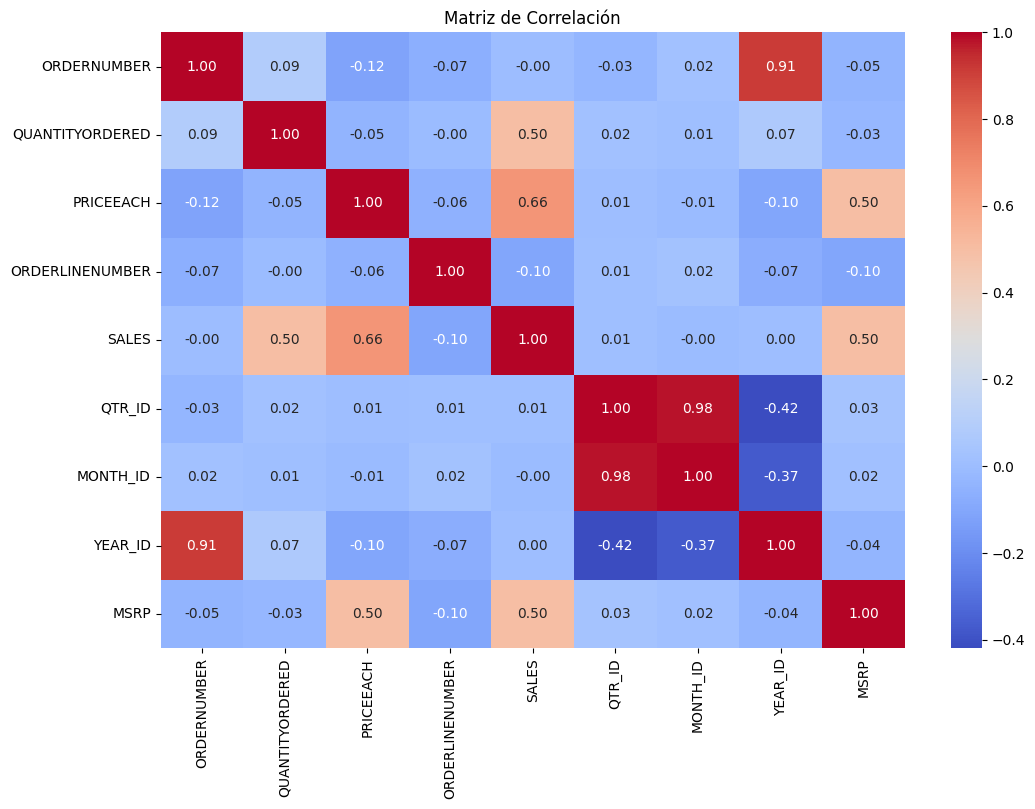

In [ ]:
# ==========================================================
# PASO 14: HEATMAP DE CORRELACIÓN
# ==========================================================
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
# ==========================================================
# PASO 15: ELIMINAR COLUMNAS INNECESARIAS
# ==========================================================
columnas_innecesarias = ['PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2']
columnas_existentes = [c for c in columnas_innecesarias if c in df.columns]

df_reducido = df.drop(columns=columnas_existentes)
print("Columnas restantes:", df_reducido.columns.tolist())

Columnas restantes: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


In [ ]:
# ==========================================================
# PASO 16: CREAR EL CORPUS (TEXTO A PARTIR DEL DATASET)
# ==========================================================
corpus = []

for _, fila in df_reducido.iterrows():
    texto = " | ".join([f"{col}: {fila[col]}" for col in df_reducido.columns])
    corpus.append(texto)

print("Cantidad de documentos en el corpus:", len(corpus))
print("\nPrimer documento:\n")
print(corpus[0][:1000])

Cantidad de documentos en el corpus: 147

Primer documento:

ORDERNUMBER: 10223 | QUANTITYORDERED: 37 | PRICEEACH: 100.0 | ORDERLINENUMBER: 1 | SALES: 3965.66 | ORDERDATE: 2004-02-20 00:00:00 | STATUS: Shipped | QTR_ID: 1 | MONTH_ID: 2 | YEAR_ID: 2004 | PRODUCTLINE: Motorcycles | MSRP: 95 | PRODUCTCODE: S10_1678 | CUSTOMERNAME: Australian Collectors, Co. | CITY: Melbourne | STATE: Victoria | POSTALCODE: 3004 | COUNTRY: Australia | TERRITORY: APAC | CONTACTLASTNAME: Ferguson | CONTACTFIRSTNAME: Peter | DEALSIZE: Medium


In [ ]:
# ==========================================================
# PASO 17: FUNCIÓN DE BÚSQUEDA (SIMULACIÓN DE RAG)
# ==========================================================
def recuperar_contexto(pregunta, corpus, top_k=3):
    pregunta = pregunta.lower()
    resultados = []

    for doc in corpus:
        score = sum(1 for palabra in pregunta.split() if palabra in doc.lower())
        resultados.append((score, doc))

    resultados.sort(reverse=True, key=lambda x: x[0])

    return [doc for score, doc in resultados[:top_k] if score > 0]

In [ ]:
# ==========================================================
# PASO 18: PROBAR LA RECUPERACIÓN
# ==========================================================
pregunta = "ventas en USA de Classic Cars"
contexto = recuperar_contexto(pregunta, corpus)

for i, doc in enumerate(contexto, 1):
    print(f"\nDocumento {i}:\n")
    print(doc[:1000])


Documento 1:

ORDERNUMBER: 10270 | QUANTITYORDERED: 21 | PRICEEACH: 100.0 | ORDERLINENUMBER: 9 | SALES: 4905.39 | ORDERDATE: 2004-07-19 00:00:00 | STATUS: Shipped | QTR_ID: 3 | MONTH_ID: 7 | YEAR_ID: 2004 | PRODUCTLINE: Classic Cars | MSRP: 214 | PRODUCTCODE: S10_1949 | CUSTOMERNAME: Souveniers And Things Co. | CITY: Chatswood | STATE: NSW | POSTALCODE: 2067 | COUNTRY: Australia | TERRITORY: APAC | CONTACTLASTNAME: Huxley | CONTACTFIRSTNAME: Adrian | DEALSIZE: Medium

Documento 2:

ORDERNUMBER: 10347 | QUANTITYORDERED: 30 | PRICEEACH: 100.0 | ORDERLINENUMBER: 1 | SALES: 3944.7 | ORDERDATE: 2004-11-29 00:00:00 | STATUS: Shipped | QTR_ID: 4 | MONTH_ID: 11 | YEAR_ID: 2004 | PRODUCTLINE: Classic Cars | MSRP: 214 | PRODUCTCODE: S10_1949 | CUSTOMERNAME: Australian Collectors, Co. | CITY: Melbourne | STATE: Victoria | POSTALCODE: 3004 | COUNTRY: Australia | TERRITORY: APAC | CONTACTLASTNAME: Ferguson | CONTACTFIRSTNAME: Peter | DEALSIZE: Medium

Documento 3:

ORDERNUMBER: 10391 | QUANTITYORD

In [ ]:
# ==========================================================
# PASO 19: FUNCIÓN DEL AGENTE
# ==========================================================
def agente(pregunta):
    contexto = recuperar_contexto(pregunta, corpus)

    if not contexto:
        return "No se encontró información relevante en el dataset."

    respuesta = f"Pregunta: {pregunta}\n\n"
    respuesta += "Contexto recuperado:\n\n"

    for i, doc in enumerate(contexto, 1):
        respuesta += f"Documento {i}:\n{doc[:1000]}\n\n"

    respuesta += (
        "Modelo recomendado para generar la respuesta final: "
        "Mistral 7B Instruct o Mixtral 8x7B Instruct."
    )

    return respuesta

In [ ]:
# ==========================================================
# PASO 20: HACER CONSULTAS AL AGENTE
# ==========================================================
print(agente("¿Qué país tuvo mayores ventas?"))

No se encontró información relevante en el dataset.


In [ ]:
# ==========================================================
# PASO 21: EJEMPLOS DE CONSULTAS
# ==========================================================
print(agente("¿Cuál fue el producto con mayores ventas?"))
print(agente("¿Qué línea de productos generó más ingresos?"))
print(agente("¿Qué ciudad tuvo mayor ganancia?"))

Pregunta: ¿Cuál fue el producto con mayores ventas?

Contexto recuperado:

Documento 1:
ORDERNUMBER: 10223 | QUANTITYORDERED: 37 | PRICEEACH: 100.0 | ORDERLINENUMBER: 1 | SALES: 3965.66 | ORDERDATE: 2004-02-20 00:00:00 | STATUS: Shipped | QTR_ID: 1 | MONTH_ID: 2 | YEAR_ID: 2004 | PRODUCTLINE: Motorcycles | MSRP: 95 | PRODUCTCODE: S10_1678 | CUSTOMERNAME: Australian Collectors, Co. | CITY: Melbourne | STATE: Victoria | POSTALCODE: 3004 | COUNTRY: Australia | TERRITORY: APAC | CONTACTLASTNAME: Ferguson | CONTACTFIRSTNAME: Peter | DEALSIZE: Medium

Documento 2:
ORDERNUMBER: 10347 | QUANTITYORDERED: 30 | PRICEEACH: 100.0 | ORDERLINENUMBER: 1 | SALES: 3944.7 | ORDERDATE: 2004-11-29 00:00:00 | STATUS: Shipped | QTR_ID: 4 | MONTH_ID: 11 | YEAR_ID: 2004 | PRODUCTLINE: Classic Cars | MSRP: 214 | PRODUCTCODE: S10_1949 | CUSTOMERNAME: Australian Collectors, Co. | CITY: Melbourne | STATE: Victoria | POSTALCODE: 3004 | COUNTRY: Australia | TERRITORY: APAC | CONTACTLASTNAME: Ferguson | CONTACTFIRSTN

# **Parte 2**


In [ ]:
# ==========================================================
# 1. INSTALAR LIBRERÍAS
# ==========================================================
!pip install pandas numpy requests -q

In [ ]:
# ==========================================================
# 2. IMPORTAR LIBRERÍAS
# ==========================================================
import pandas as pd
import numpy as np
import requests

In [ ]:
# ==========================================================
# 3. SUBIR DATASET
# ==========================================================
from google.colab import files
uploaded = files.upload()

Saving sales_data_sample.csv to sales_data_sample (5).csv


In [ ]:
# ==========================================================
# 4. CARGAR DATASET
# ==========================================================
df = pd.read_csv("sales_data_sample.csv", encoding="latin1")
df = df.dropna()

df["SALES"] = pd.to_numeric(df["SALES"], errors="coerce")
df["QUANTITYORDERED"] = pd.to_numeric(df["QUANTITYORDERED"], errors="coerce")

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
10,10223,37,100.00,1,3965.66,2/20/2004 0:00,Shipped,1,2,2004,...,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium
21,10361,20,72.55,13,1451.00,12/17/2004 0:00,Shipped,4,12,2004,...,"Monitor Money Building, 815 Pacific Hwy",Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Small
40,10270,21,100.00,9,4905.39,7/19/2004 0:00,Shipped,3,7,2004,...,"Monitor Money Building, 815 Pacific Hwy",Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Medium
47,10347,30,100.00,1,3944.70,11/29/2004 0:00,Shipped,4,11,2004,...,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium
51,10391,24,100.00,4,2416.56,3/9/2005 0:00,Shipped,1,3,2005,...,201 Miller Street,Level 15,North Sydney,NSW,2060,Australia,APAC,O'Hara,Anna,Small


In [ ]:
MISTRAL_API_KEY = "6NFfPwAkspFUiV0YNxFsjRxMRWgA1MKR"

In [ ]:
def call_mistral(prompt):
    url = "https://api.mistral.ai/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {MISTRAL_API_KEY}",
        "Content-Type": "application/json"
    }

    data = {
        "model": "mistral-large-latest",
        "messages": [
            {"role": "system", "content": "Eres un analista de datos experto. Responde SOLO basado en los datos entregados."},
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.2
    }

    response = requests.post(url, headers=headers, json=data)
    return response.json()["choices"][0]["message"]["content"]

In [ ]:
def producto_mas_vendido(df):
    return df.groupby("PRODUCTCODE")["QUANTITYORDERED"].sum().sort_values(ascending=False).head(1)

def ingresos_por_linea(df):
    return df.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)

def ventas_por_pais(df):
    return df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False)

def ventas_por_ciudad(df):
    return df.groupby("CITY")["SALES"].sum().sort_values(ascending=False)

In [ ]:
def agente(pregunta):

    pregunta = pregunta.lower()

    # 📦 PRODUCTO MÁS VENDIDO
    if "producto" in pregunta and "vendido" in pregunta:

        resultado = producto_mas_vendido(df)

        prompt = f"""
Resultado del análisis de productos:

{resultado.to_string()}

Explica cuál es el producto más vendido y por qué.
"""

        return call_mistral(prompt)

    # 💰 LÍNEA DE PRODUCTOS
    elif "línea" in pregunta or "ingresos" in pregunta:

        resultado = ingresos_por_linea(df)

        prompt = f"""
Ingresos por línea de producto:

{resultado.to_string()}

Indica cuál es la línea con más ingresos.
"""

        return call_mistral(prompt)

    # 🌍 PAÍS
    elif "país" in pregunta:

        resultado = ventas_por_pais(df)

        prompt = f"""
Ventas por país:

{resultado.to_string()}

Indica el país con más ventas.
"""

        return call_mistral(prompt)

    # 🏙️ CIUDAD
    elif "ciudad" in pregunta:

        resultado = ventas_por_ciudad(df)

        prompt = f"""
Ventas por ciudad:

{resultado.to_string()}

Indica la ciudad con más ventas.
"""

        return call_mistral(prompt)

    else:
        return "Pregunta no soportada."

In [ ]:
print(agente("¿Cuál fue el producto más vendido?"))
print(agente("¿Qué línea generó más ingresos?"))
print(agente("¿Qué país tuvo mayores ventas?"))
print(agente("¿Qué ciudad tuvo más ventas?"))

Basado en los datos entregados, el producto más vendido es el identificado con el código **"S18_2949"**, con un total de **157 unidades vendidas**.

No hay información adicional sobre otros productos para comparar, por lo que este es el único dato concluyente.
Basado en los datos entregados, la línea de producto con más ingresos es:

**Classic Cars** con **161870.46**.
Basado en los datos entregados, el país con más ventas es:

**Australia** (506,562.52).
Basado en los datos entregados, la ciudad con más ventas es **Melbourne** con **200995.41**.
